# Глобальный супермаркет — разведочный анализ

Pandas · NumPy · Matplotlib · DuckDB

In [1]:
from pathlib import Path
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
DB = ROOT / 'data' / 'processed' / 'superstore.duckdb'
con = duckdb.connect(str(DB))
df = con.execute('SELECT * FROM orders LIMIT 5').df()
df

,category,city,country,customer_id,customer_name,discount,market,record_count,order_date,order_id,...,ship_date,ship_mode,shipping_cost,state,sub_category,year,market_group,weeknum,delivery_days,profit_margin
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-08,CA-2011-130813,...,2011-01-11,Second Class,4.37,California,Paper,2011,North America,2,3,0.491116
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-22,CA-2011-148614,...,2011-01-27,Standard Class,0.94,California,Paper,2011,North America,4,5,0.489095
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-06,CA-2011-118962,...,2011-08-11,Standard Class,1.81,California,Paper,2011,North America,32,5,0.468657
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-06,CA-2011-118962,...,2011-08-11,Standard Class,4.59,California,Paper,2011,North America,32,5,0.479827
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-10-01,CA-2011-146969,...,2011-10-06,Standard Class,1.32,California,Paper,2011,North America,40,5,0.518400


In [2]:
mart = con.execute('''
    SELECT region, year, revenue, profit, avg_margin
    FROM mart_region_year
    ORDER BY revenue DESC
    LIMIT 10
''').df()
mart

,region,year,revenue,profit,avg_margin
0,Oceania,2014,314741.0,32030.2020,0.090692
1,Central,2014,308437.0,35142.1095,0.173040
2,Oceania,2013,268970.0,28831.7790,0.097070
3,West,2014,250664.0,43900.6256,0.221448
4,Central,2013,230113.0,32416.4775,0.153371
5,North Asia,2014,218975.0,46793.9940,0.233025
6,Central,2014,216533.0,35956.0470,0.180567
7,East,2014,213259.0,33195.3462,0.166113
8,Central Asia,2014,205034.0,48807.6750,0.233112
9,Oceania,2012,203960.0,25528.7220,0.099253


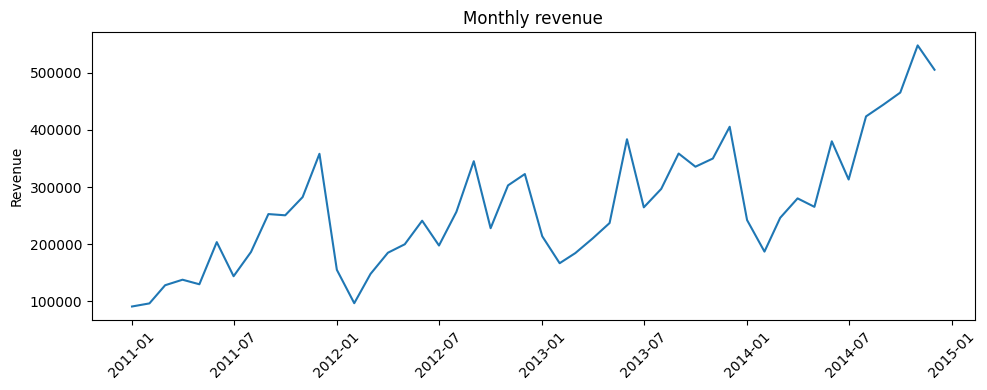

In [3]:
ts = con.execute('''
    SELECT DATE_TRUNC('month', order_date) AS month, SUM(sales) AS revenue
    FROM orders
    GROUP BY 1 ORDER BY 1
''').df()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ts['month'], ts['revenue'])
ax.set_title('Помесячная выручка')
ax.set_ylabel('Выручка')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()